# Tel Aviv dew point — ERA5-Land hourly, 1950 → 2026

First look at how 2 m dew point behaves over time, as raw hourly values and as daily min / mean / max.

**Data** — Open-Meteo historical archive, `models=era5_land`, `cell_selection=nearest`, at the product cell
**32.1°N 34.8°E** (`cells.csv` id 555, "Tel Aviv, Israel"; Open-Meteo answered for grid point 32.1, 34.800003, 7 m).
Pulled once by `pull_openmeteo_hourly.py` (8 requests, ~200 weighted Open-Meteo calls) and cached in `data/` —
re-running this notebook costs zero API calls.

**Local time** — timestamps arrive in UTC and are shifted by the cell's solar offset `round(lon / 15) = +2 h`,
the same DST-free rule `download_cells.py` uses to bucket the production archive into local days.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

DATA_FILE = Path("data/dew_point_2m_era5_land_32.1_34.8_hourly.csv.gz")
CELL_LAT, CELL_LON = 32.1, 34.8
SOLAR_OFFSET_HOURS = int(round(CELL_LON / 15))  # +2 h, DST-free, as in download_cells.py

raw = pd.read_csv(DATA_FILE, parse_dates=["time_utc"])
local_time = raw["time_utc"].dt.tz_convert(None) + pd.Timedelta(hours=SOLAR_OFFSET_HOURS)
hourly = pd.Series(raw["dew_point_2m"].to_numpy(), index=local_time, name="dew_point_C")

print(f"{len(hourly):,} hours, {hourly.index.min()} → {hourly.index.max()} (local solar time), "
      f"{hourly.isna().sum()} missing")
hourly.describe().round(2)

671,832 hours, 1950-01-01 02:00:00 → 2026-08-23 01:00:00 (local solar time), 1 missing


count    671831.00
mean         13.60
std           5.44
min         -15.70
25%           9.30
50%          13.50
75%          18.50
max          26.50
Name: dew_point_C, dtype: float64

In [2]:
# Plot style shared by every figure
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True, "grid.color": "#e5e5e5", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlelocation": "center",
})
COLOR_HOURLY = "#2a2f3a"
COLOR_MAX, COLOR_MEAN, COLOR_MIN = "#eb6834", "#1baf7a", "#2a78d6"

last_hour = hourly.index.max()
WINDOWS = [
    ("Whole record, 1950 → 2026", hourly.index.min()),
    ("Last 10 years", last_hour - pd.DateOffset(years=10)),
    ("Last 1 year", last_hour - pd.DateOffset(years=1)),
]


def format_time_axis(axis, span_days):
    """Tick density that suits the window: decades, years, or months."""
    if span_days > 20 * 365:
        axis.xaxis.set_major_locator(mdates.YearLocator(10))
        axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    elif span_days > 2 * 365:
        axis.xaxis.set_major_locator(mdates.YearLocator(1))
        axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    else:
        axis.xaxis.set_major_locator(mdates.MonthLocator())
        axis.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))


def three_windows(figure_title, draw_panel):
    """One figure, three stacked panels (whole record / 10 y / 1 y); draw_panel(axis, window_start)."""
    figure, axes = plt.subplots(3, 1, figsize=(14, 11))
    for axis, (title, window_start) in zip(axes, WINDOWS):
        draw_panel(axis, window_start)
        axis.set_title(title)
        axis.set_ylabel("dew point (°C)")
        axis.set_xlim(window_start, last_hour)
        format_time_axis(axis, (last_hour - window_start).days)
    figure.suptitle(figure_title, fontsize=14)
    figure.tight_layout()
    return figure

## Hourly values

Every hour as one thin line. The whole-record panel is ~670k points, so it reads as the envelope of the
seasonal cycle; the shorter windows show the actual hour-to-hour behaviour.

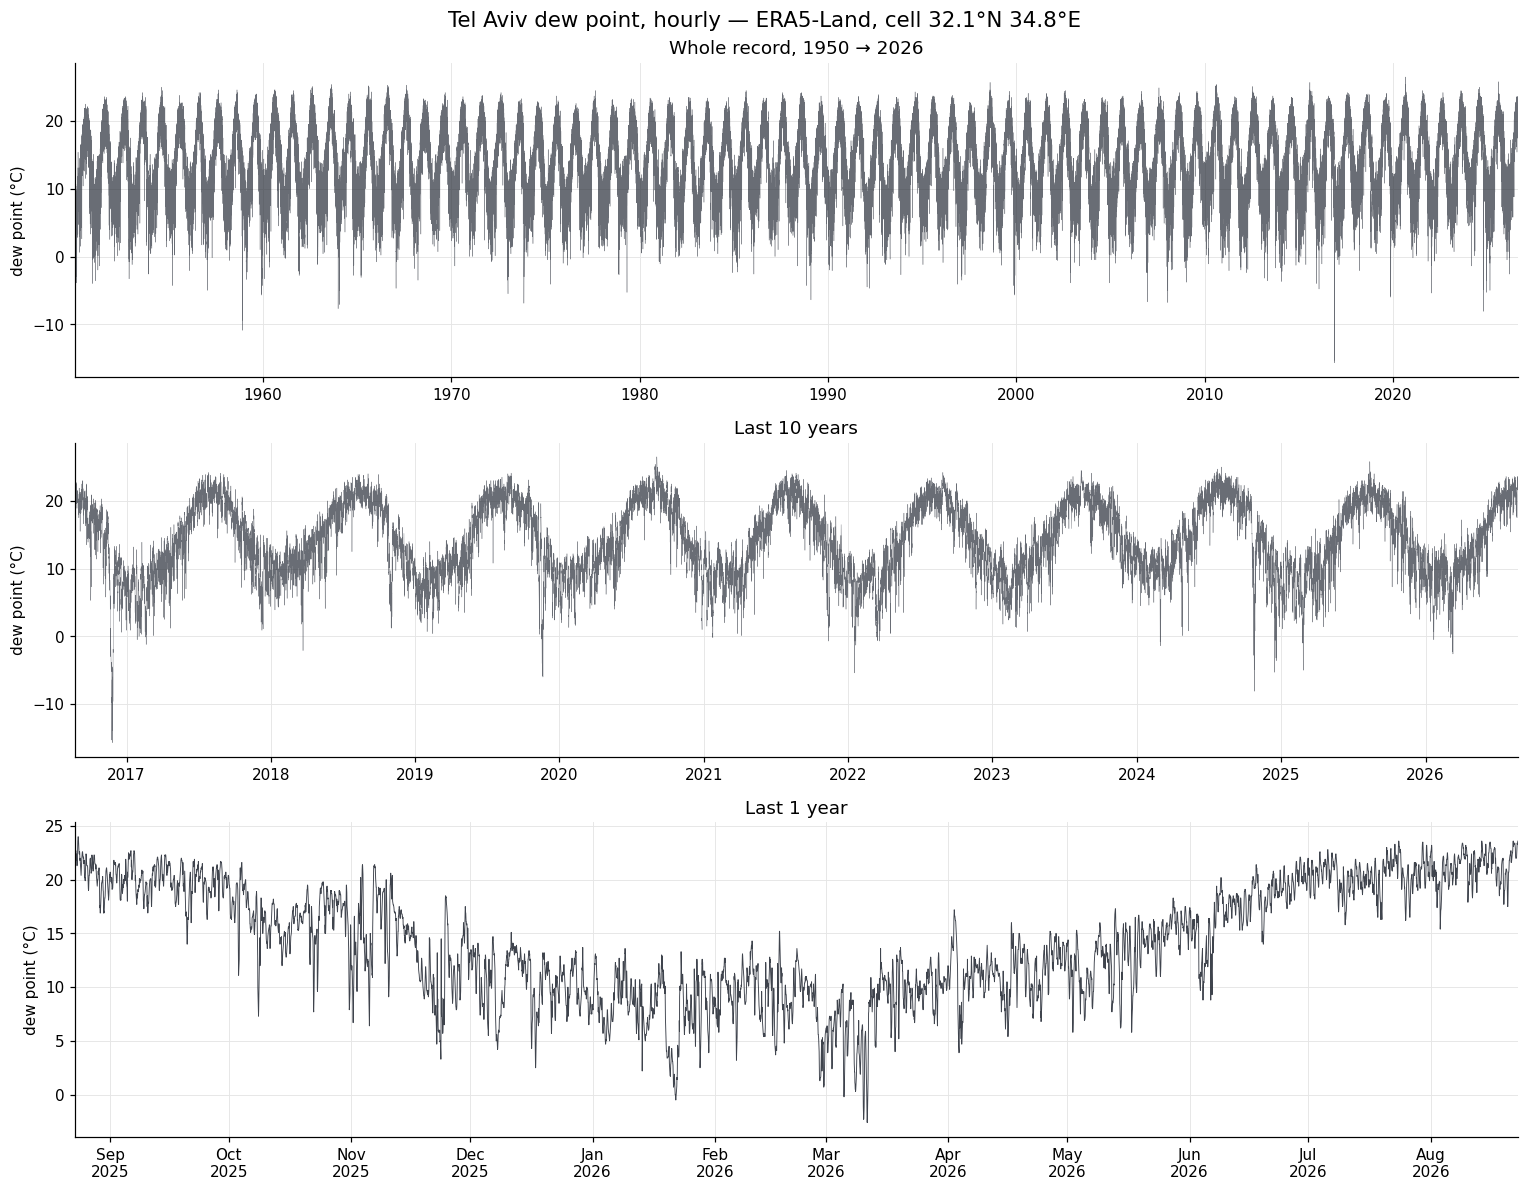

In [3]:
def draw_hourly(axis, window_start):
    window = hourly[window_start:]
    is_dense = len(window) > 50_000
    axis.plot(window.index, window.to_numpy(), color=COLOR_HOURLY,
              linewidth=0.25 if is_dense else 0.6, alpha=0.7 if is_dense else 0.9,
              rasterized=is_dense)


three_windows("Tel Aviv dew point, hourly — ERA5-Land, cell 32.1°N 34.8°E", draw_hourly);

## Daily min / mean / max

Bucketed by the cell's local solar day (00:00–23:00 at UTC+2); only days with all 24 hours present are kept,
the same whole-day rule as the production archive.

In [4]:
local_day = hourly.index.floor("D")
hours_present = hourly.groupby(local_day).count()
daily = hourly.groupby(local_day).agg(["min", "mean", "max"])
daily.columns = ["min", "mean", "max"]
whole_days = hours_present == 24
daily = daily[whole_days]

print(f"{len(daily):,} whole local days kept, {(~whole_days).sum()} partial day(s) dropped")
daily.describe().round(2)

27,992 whole local days kept, 2 partial day(s) dropped


,min,mean,max
count,27992.00,27992.00,27992.00
mean,11.59,13.60,15.61
std,5.61,5.25,5.04
min,-15.70,-11.45,-9.00
25%,7.20,9.32,11.40
50%,11.30,13.35,15.50
75%,16.70,18.48,20.30
max,23.90,24.73,26.50


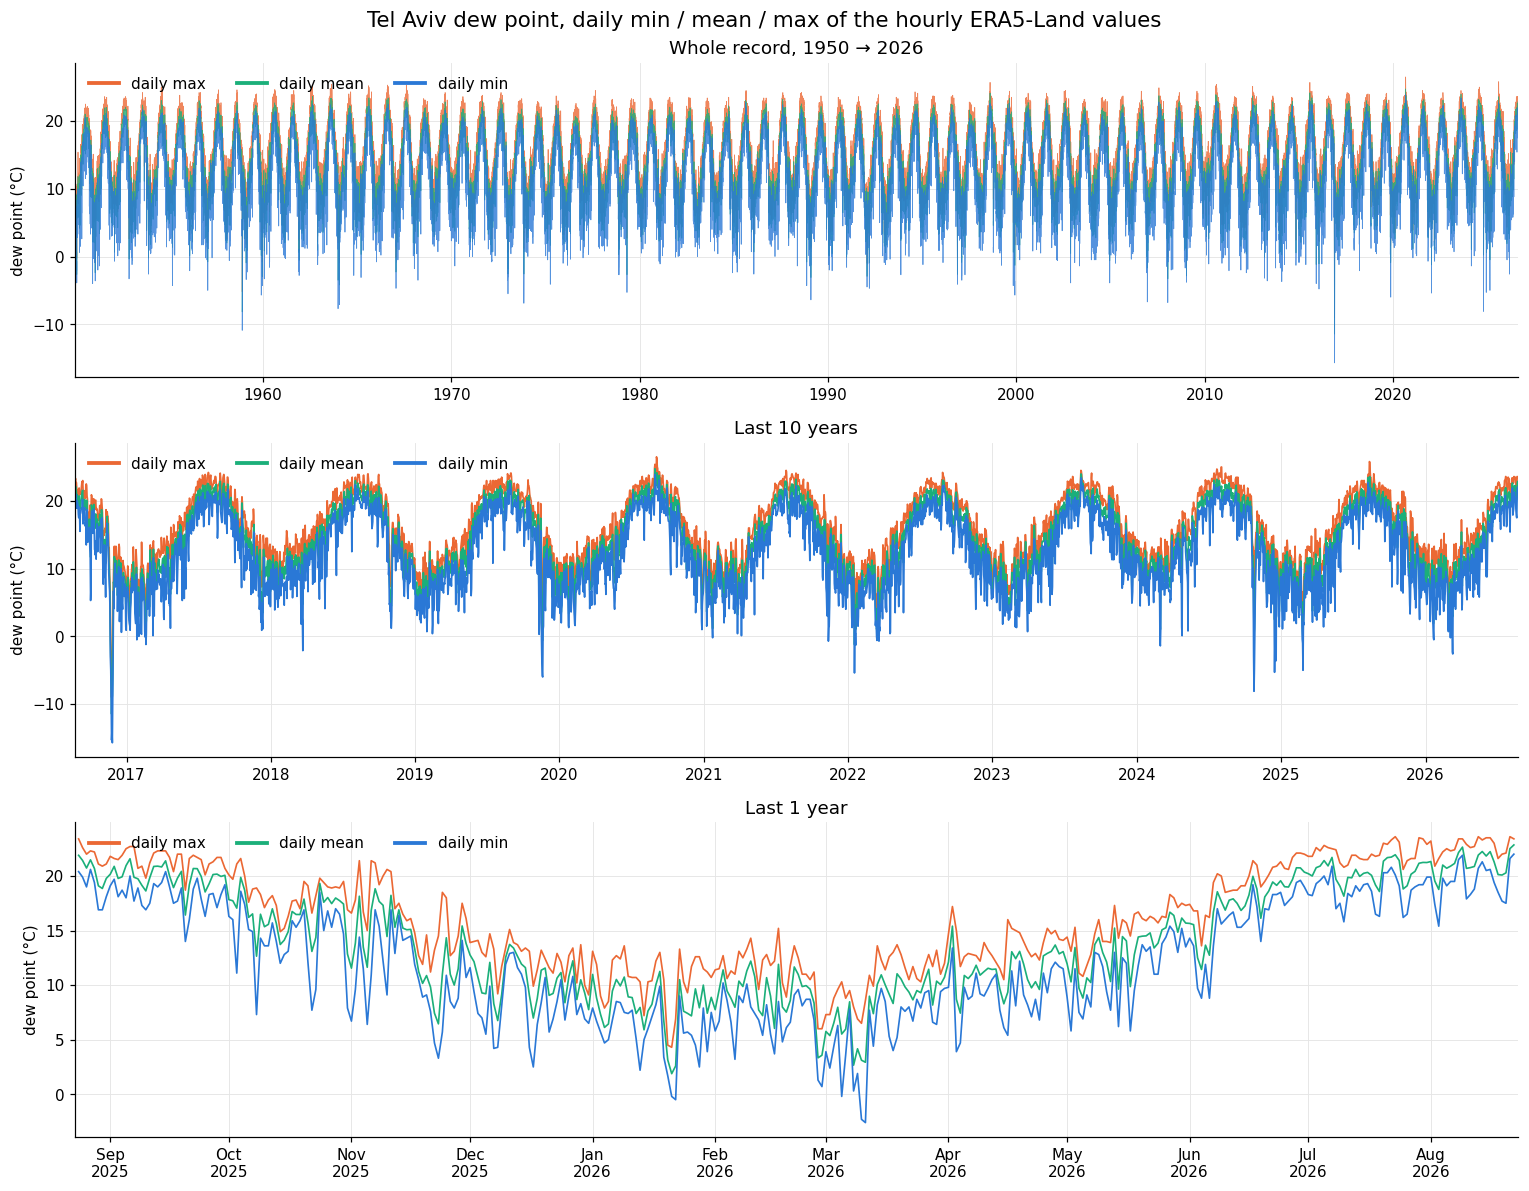

In [5]:
def draw_daily(axis, window_start):
    window = daily[window_start:]
    is_dense = len(window) > 5_000
    line_width = 0.5 if is_dense else 1.1
    for column, color, label in [("max", COLOR_MAX, "daily max"),
                                 ("mean", COLOR_MEAN, "daily mean"),
                                 ("min", COLOR_MIN, "daily min")]:
        axis.plot(window.index, window[column].to_numpy(), color=color, linewidth=line_width,
                  alpha=0.8 if is_dense else 1.0, label=label, rasterized=is_dense)
    legend = axis.legend(loc="upper left", ncol=3, frameon=False)
    for handle in legend.get_lines():   # legend swatches stay readable even when the data lines are hairlines
        handle.set_linewidth(2.5)
        handle.set_alpha(1.0)


three_windows("Tel Aviv dew point, daily min / mean / max of the hourly ERA5-Land values", draw_daily);